AO* ALGORITHM RESULT
Optimal Cost: 6

Optimal Solution Subgraph:
A -> C
C -> JK
JK -> J
JK -> K

Final Solution:
A -> C -> (J AND K)

Total Cost = 6


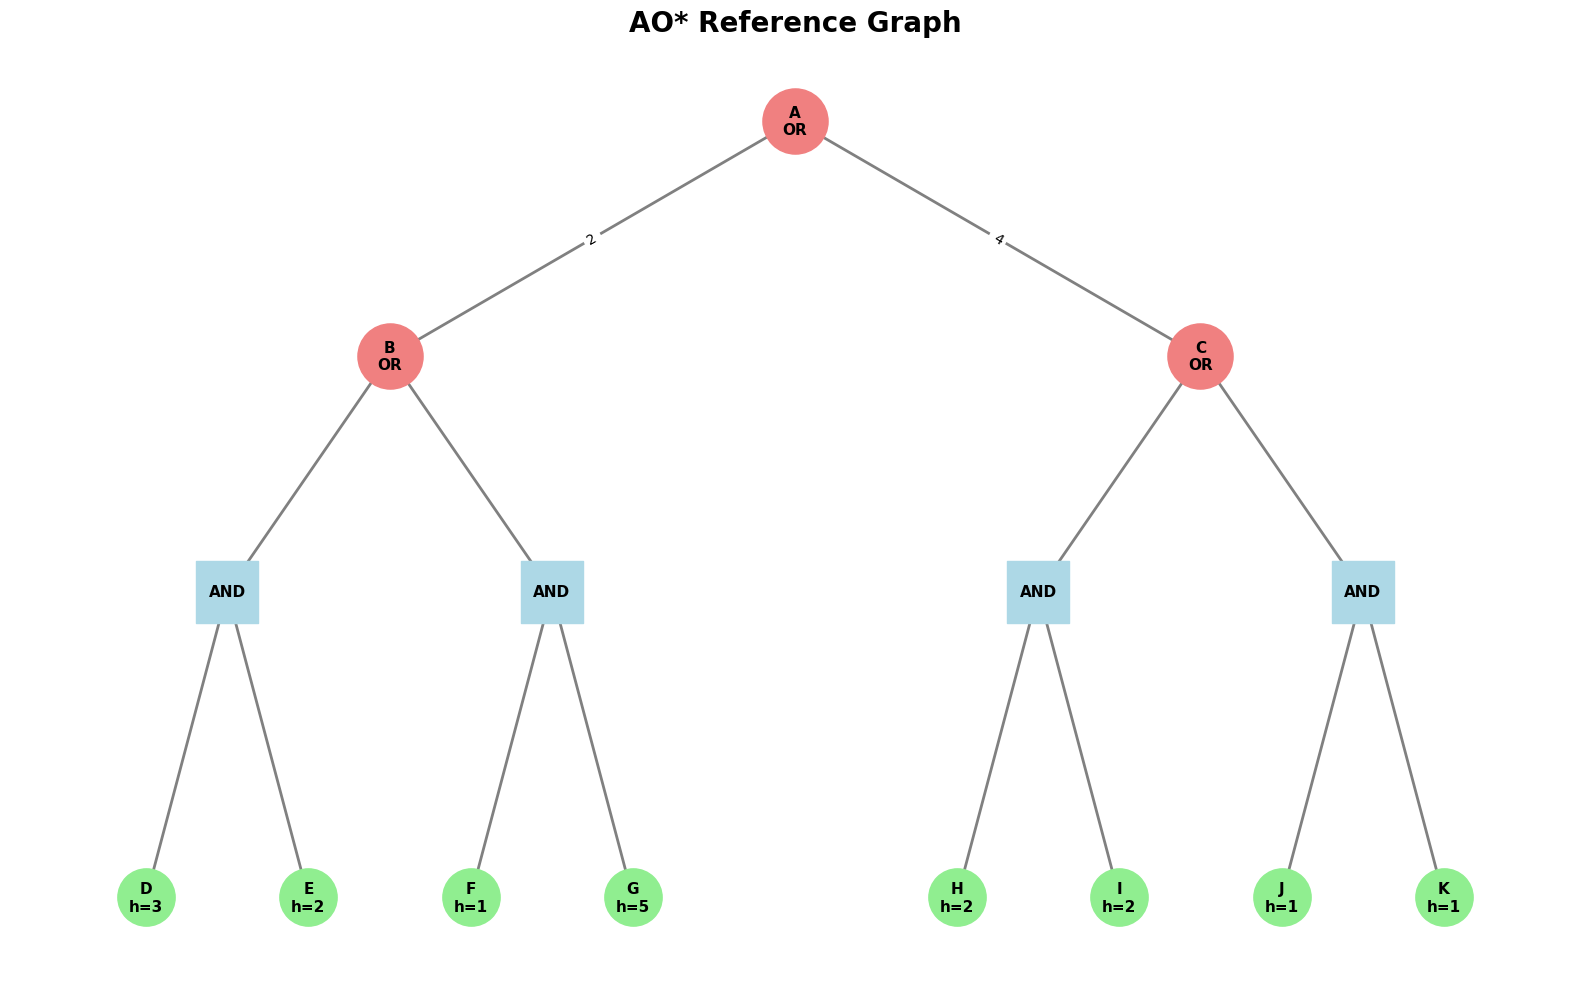

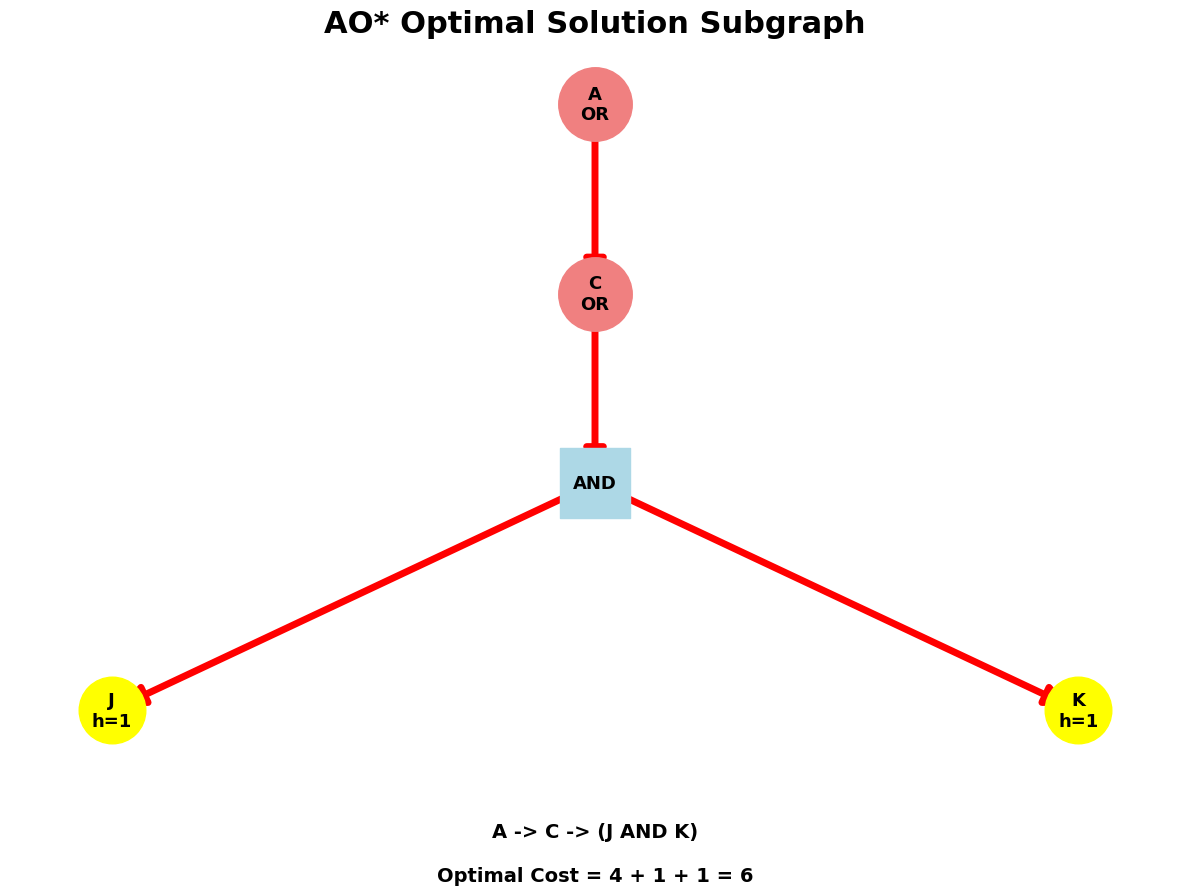

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

graph = {
    "A": {
        "type": "OR",
        "children": [
            ("B", 2),
            ("C", 4)
        ]
    },
    "B": {
        "type": "OR",
        "children": [
            ("DE", 0),
            ("FG", 0)
        ]
    },
    "C": {
        "type": "OR",
        "children": [
            ("HI", 0),
            ("JK", 0)
        ]
    },
    "DE": {
        "type": "AND",
        "children": [
            ("D", 0),
            ("E", 0)
        ]
    },
    "FG": {
        "type": "AND",
        "children": [
            ("F", 0),
            ("G", 0)
        ]
    },
    "HI": {
        "type": "AND",
        "children": [
            ("H", 0),
            ("I", 0)
        ]
    },
    "JK": {
        "type": "AND",
        "children": [
            ("J", 0),
            ("K", 0)
        ]
    },
    "D": {"type": "GOAL", "cost": 3},
    "E": {"type": "GOAL", "cost": 2},
    "F": {"type": "GOAL", "cost": 1},
    "G": {"type": "GOAL", "cost": 5},
    "H": {"type": "GOAL", "cost": 2},
    "I": {"type": "GOAL", "cost": 2},
    "J": {"type": "GOAL", "cost": 1},
    "K": {"type": "GOAL", "cost": 1}
}

def ao_star(node):
    node_type = graph[node]["type"]
    if node_type == "GOAL":
        return graph[node]["cost"], []
    if node_type == "AND":
        total_cost = 0
        solution_edges = []
        for child, edge_cost in graph[node]["children"]:
            child_cost, child_edges = ao_star(child)
            total_cost += edge_cost + child_cost
            solution_edges.append((node, child))
            solution_edges.extend(child_edges)
        return total_cost, solution_edges
    if node_type == "OR":
        alternatives = []
        for child, edge_cost in graph[node]["children"]:
            child_cost, child_edges = ao_star(child)
            total_cost = edge_cost + child_cost
            alternatives.append((total_cost, child, child_edges))
        best_cost, best_child, best_edges = min(
            alternatives,
            key=lambda x: x[0]
        )
        solution_edges = [(node, best_child)]
        solution_edges.extend(best_edges)
        return best_cost, solution_edges

optimal_cost, optimal_edges = ao_star("A")
print("=" * 60)
print("AO* ALGORITHM RESULT")
print("=" * 60)

print("Optimal Cost:", optimal_cost)
print("\nOptimal Solution Subgraph:")
for source, target in optimal_edges:
    print(source, "->", target)

print("\nFinal Solution:")
print("A -> C -> (J AND K)")
print("\nTotal Cost = 6")

G = nx.DiGraph()
for node in graph:
    G.add_node(node)
    if graph[node]["type"] != "GOAL":
        for child, cost in graph[node]["children"]:
            G.add_edge(node, child, weight=cost)

reference_pos = {
    "A": (0, 6),
    "B": (-3, 5),
    "C": (3, 5),
    "DE": (-4.2, 4),
    "FG": (-1.8, 4),
    "HI": (1.8, 4),
    "JK": (4.2, 4),
    "D": (-4.8, 2.7),
    "E": (-3.6, 2.7),
    "F": (-2.4, 2.7),
    "G": (-1.2, 2.7),
    "H": (1.2, 2.7),
    "I": (2.4, 2.7),
    "J": (3.6, 2.7),
    "K": (4.8, 2.7)
}

labels = {
    "A": "A\nOR",
    "B": "B\nOR",
    "C": "C\nOR",
    "DE": "AND",
    "FG": "AND",
    "HI": "AND",
    "JK": "AND",
    "D": "D\nh=3",
    "E": "E\nh=2",
    "F": "F\nh=1",
    "G": "G\nh=5",
    "H": "H\nh=2",
    "I": "I\nh=2",
    "J": "J\nh=1",
    "K": "K\nh=1"
}

plt.figure(figsize=(16, 10))

or_nodes = [n for n in G.nodes() if graph[n]["type"] == "OR"]
and_nodes = [n for n in G.nodes() if graph[n]["type"] == "AND"]
goal_nodes = [n for n in G.nodes() if graph[n]["type"] == "GOAL"]

nx.draw_networkx_edges(
    G,
    reference_pos,
    edge_color="gray",
    width=2,
    arrows=True,
    arrowsize=20
)

nx.draw_networkx_nodes(
    G,
    reference_pos,
    nodelist=or_nodes,
    node_shape="o",
    node_color="lightcoral",
    node_size=2200
)

nx.draw_networkx_nodes(
    G,
    reference_pos,
    nodelist=and_nodes,
    node_shape="s",
    node_color="lightblue",
    node_size=2000
)

nx.draw_networkx_nodes(
    G,
    reference_pos,
    nodelist=goal_nodes,
    node_shape="o",
    node_color="lightgreen",
    node_size=1700
)

nx.draw_networkx_labels(
    G,
    reference_pos,
    labels=labels,
    font_size=11,
    font_weight="bold"
)

edge_labels = nx.get_edge_attributes(G, "weight")
edge_labels = {edge: value for edge, value in edge_labels.items() if value != 0}

nx.draw_networkx_edge_labels(
    G,
    reference_pos,
    edge_labels=edge_labels
)

plt.title("AO* Reference Graph", fontsize=20, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.savefig("AO_star_REFERENCE_GRAPH.png", dpi=300, bbox_inches="tight")
plt.show()

S = nx.DiGraph()
for source, target in optimal_edges:
    S.add_edge(source, target)

solution_pos = {
    "A": (0, 4),
    "C": (0, 3),
    "JK": (0, 2),
    "J": (-1.2, 0.8),
    "K": (1.2, 0.8)
}

plt.figure(figsize=(12, 9))

nx.draw_networkx_edges(
    S,
    solution_pos,
    edge_color="red",
    width=5,
    arrows=True,
    arrowsize=30
)

nx.draw_networkx_nodes(
    S,
    solution_pos,
    nodelist=["A", "C"],
    node_shape="o",
    node_color="lightcoral",
    node_size=2800
)

nx.draw_networkx_nodes(
    S,
    solution_pos,
    nodelist=["JK"],
    node_shape="s",
    node_color="lightblue",
    node_size=2500
)

nx.draw_networkx_nodes(
    S,
    solution_pos,
    nodelist=["J", "K"],
    node_shape="o",
    node_color="yellow",
    node_size=2300
)

solution_labels = {
    "A": "A\nOR",
    "C": "C\nOR",
    "JK": "AND",
    "J": "J\nh=1",
    "K": "K\nh=1"
}

nx.draw_networkx_labels(
    S,
    solution_pos,
    labels=solution_labels,
    font_size=13,
    font_weight="bold"
)

plt.title("AO* Optimal Solution Subgraph", fontsize=22, fontweight="bold")
plt.text(
    0,
    -0.1,
    "A -> C -> (J AND K)\n\nOptimal Cost = 4 + 1 + 1 = 6",
    ha="center",
    fontsize=14,
    fontweight="bold"
)
plt.axis("off")
plt.tight_layout()
plt.savefig("AO_star_OPTIMAL_SOLUTION.png", dpi=300, bbox_inches="tight")
plt.show()

                    AO* ALGORITHM RESULT

Optimal Cost: 9

Optimal Solution Subgraph:
PROCESS PIPELINE -> DEEP LEARNING
DEEP LEARNING -> FEATURE EXTRACTION
FEATURE EXTRACTION -> CONV EXTRACTOR
DEEP LEARNING -> ARCHITECTURE OPTIMIZATION
ARCHITECTURE OPTIMIZATION -> BAYESIAN TUNING

                    FINAL SOLUTION

Selected Strategy:
PROCESS PIPELINE -> DEEP LEARNING
DEEP LEARNING -> FEATURE EXTRACTION AND ARCHITECTURE OPTIMIZATION

Total Cost = 9


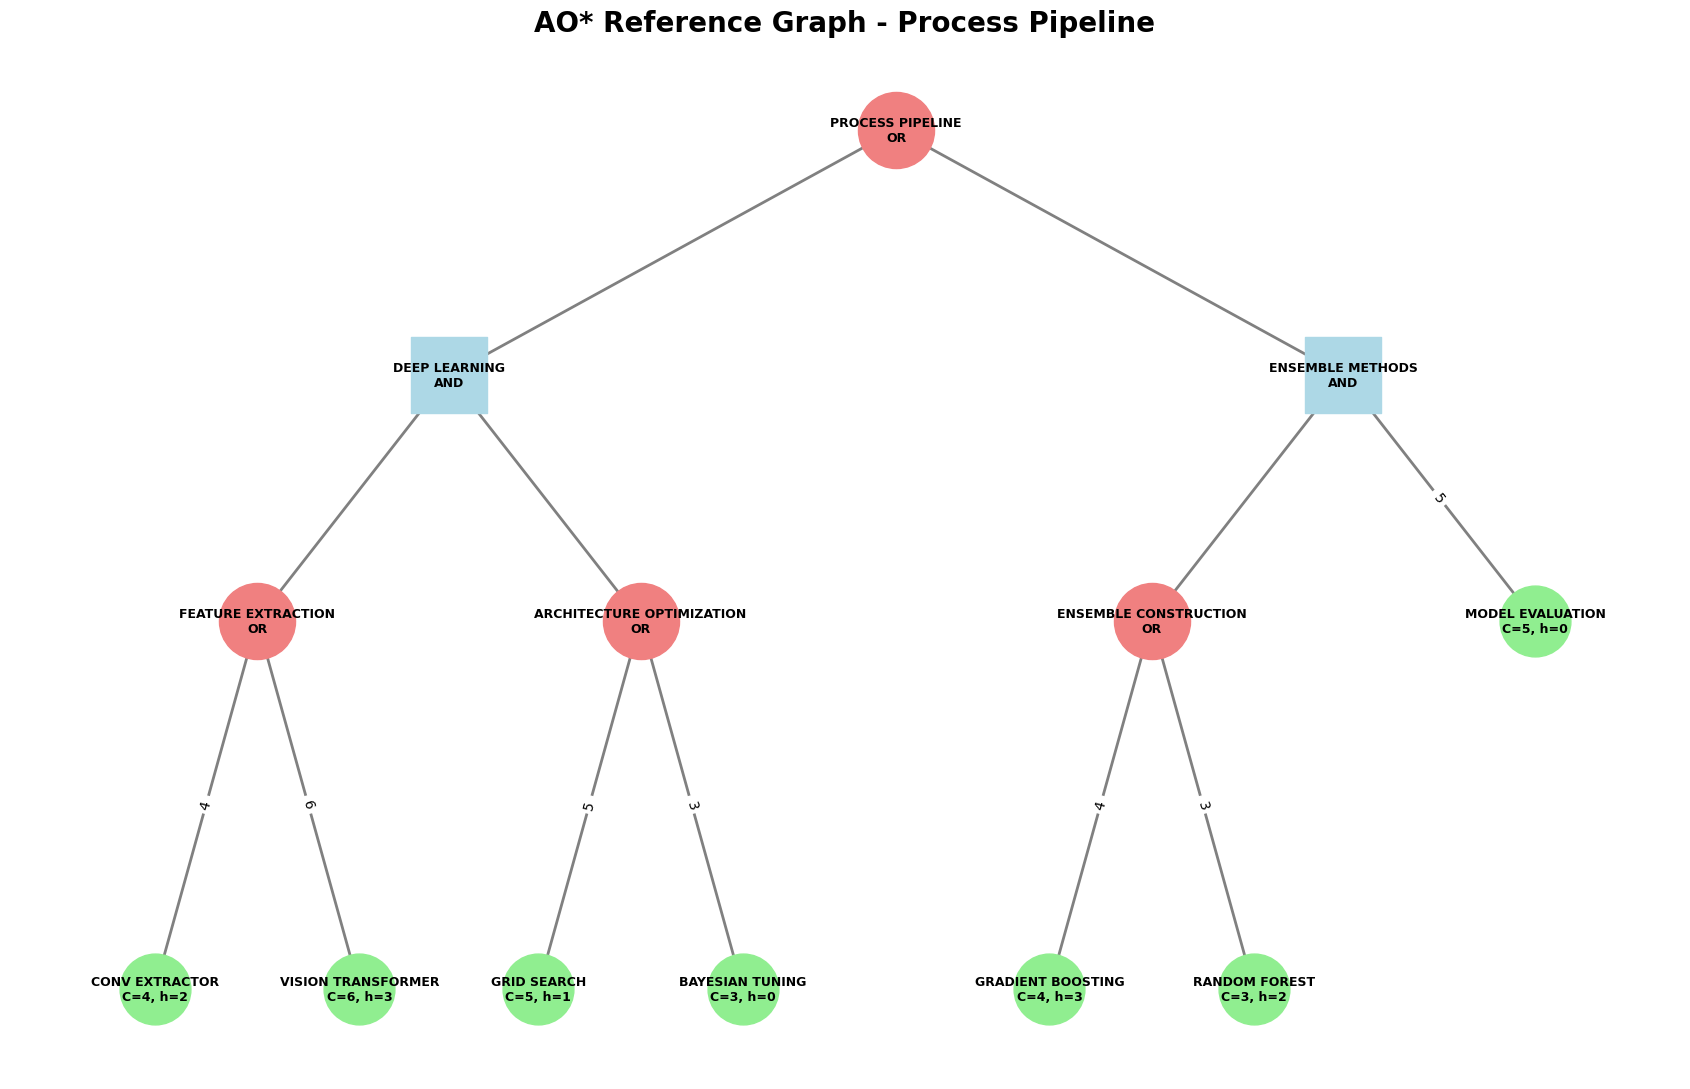

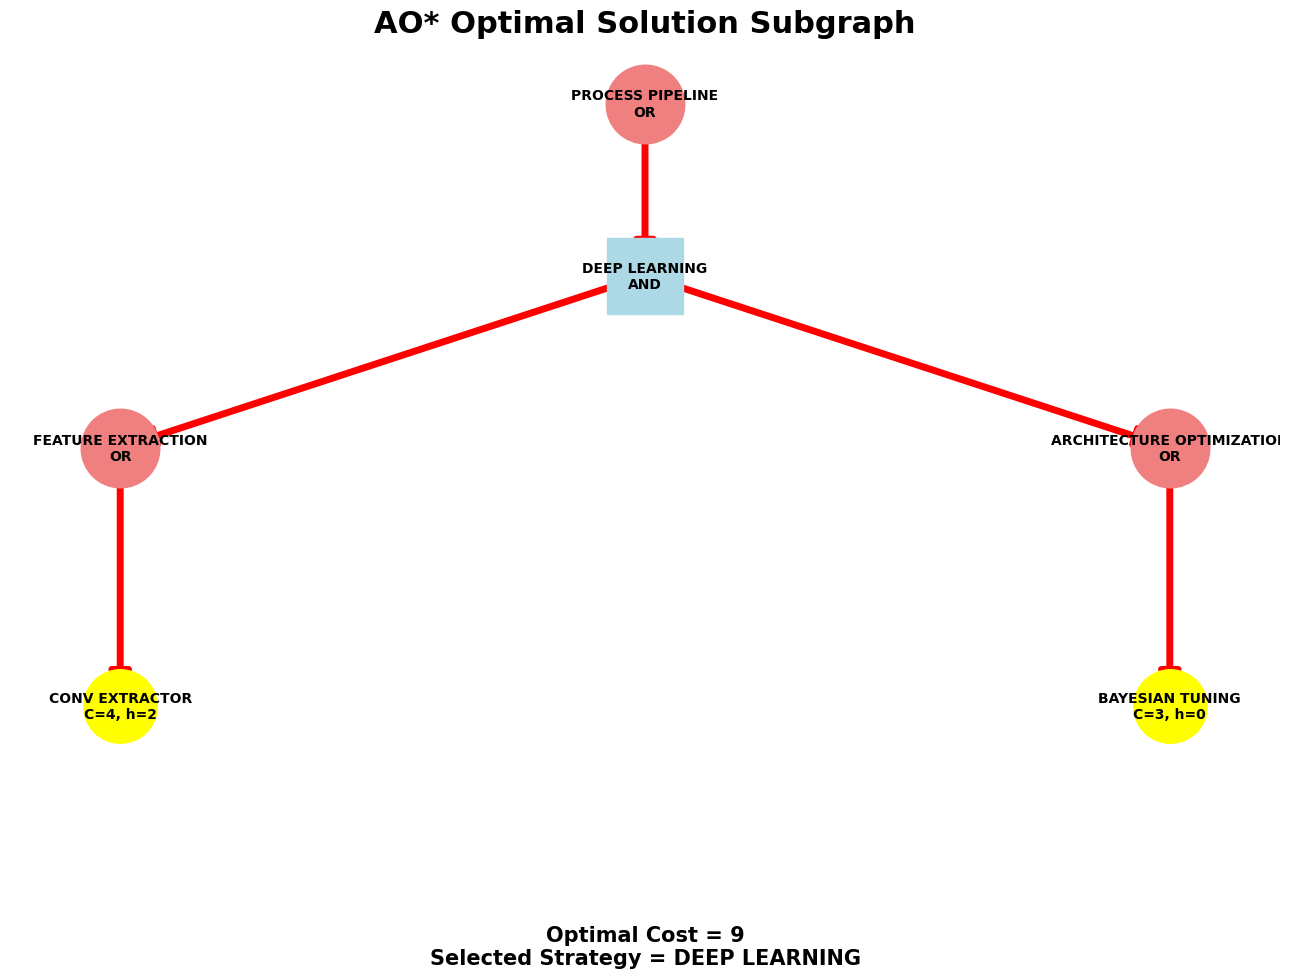

In [2]:

import networkx as nx
import matplotlib.pyplot as plt


# ============================================================
# AO* GRAPH
# ============================================================

graph = {

    "PROCESS PIPELINE": {
        "type": "OR",
        "children": [
            ("DEEP LEARNING", 0),
            ("ENSEMBLE METHODS", 0)
        ]
    },


    # --------------------------------------------------------
    # DEEP LEARNING
    # --------------------------------------------------------

    "DEEP LEARNING": {
        "type": "AND",
        "children": [
            ("FEATURE EXTRACTION", 0),
            ("ARCHITECTURE OPTIMIZATION", 0)
        ]
    },


    # --------------------------------------------------------
    # FEATURE EXTRACTION
    # --------------------------------------------------------

    "FEATURE EXTRACTION": {
        "type": "OR",
        "children": [
            ("CONV EXTRACTOR", 4),
            ("VISION TRANSFORMER", 6)
        ]
    },

    "CONV EXTRACTOR": {
        "type": "GOAL",
        "cost": 2
    },

    "VISION TRANSFORMER": {
        "type": "GOAL",
        "cost": 3
    },


    # --------------------------------------------------------
    # ARCHITECTURE OPTIMIZATION
    # --------------------------------------------------------

    "ARCHITECTURE OPTIMIZATION": {
        "type": "OR",
        "children": [
            ("GRID SEARCH", 5),
            ("BAYESIAN TUNING", 3)
        ]
    },

    "GRID SEARCH": {
        "type": "GOAL",
        "cost": 1
    },

    "BAYESIAN TUNING": {
        "type": "GOAL",
        "cost": 0
    },


    # --------------------------------------------------------
    # ENSEMBLE METHODS
    # --------------------------------------------------------

    "ENSEMBLE METHODS": {
        "type": "AND",
        "children": [
            ("ENSEMBLE CONSTRUCTION", 0),
            ("MODEL EVALUATION", 5)
        ]
    },


    # --------------------------------------------------------
    # ENSEMBLE CONSTRUCTION
    # --------------------------------------------------------

    "ENSEMBLE CONSTRUCTION": {
        "type": "OR",
        "children": [
            ("GRADIENT BOOSTING", 4),
            ("RANDOM FOREST", 3)
        ]
    },

    "GRADIENT BOOSTING": {
        "type": "GOAL",
        "cost": 3
    },

    "RANDOM FOREST": {
        "type": "GOAL",
        "cost": 2
    },


    # --------------------------------------------------------
    # MODEL EVALUATION
    # --------------------------------------------------------

    "MODEL EVALUATION": {
        "type": "GOAL",
        "cost": 0
    }
}


# ============================================================
# AO* ALGORITHM
# ============================================================

def ao_star(node):

    node_type = graph[node]["type"]


    # --------------------------------------------------------
    # GOAL NODE
    # --------------------------------------------------------

    if node_type == "GOAL":

        return graph[node]["cost"], []


    # --------------------------------------------------------
    # AND NODE
    # --------------------------------------------------------

    if node_type == "AND":

        total_cost = 0

        solution_edges = []


        for child, edge_cost in graph[node]["children"]:

            child_cost, child_edges = ao_star(child)


            total_cost += edge_cost + child_cost


            solution_edges.append(
                (node, child)
            )

            solution_edges.extend(
                child_edges
            )


        return total_cost, solution_edges


    # --------------------------------------------------------
    # OR NODE
    # --------------------------------------------------------

    if node_type == "OR":

        alternatives = []


        for child, edge_cost in graph[node]["children"]:

            child_cost, child_edges = ao_star(child)


            total_cost = edge_cost + child_cost


            alternatives.append(
                (
                    total_cost,
                    child,
                    child_edges
                )
            )


        # Select minimum-cost alternative

        best_cost, best_child, best_edges = min(
            alternatives,
            key=lambda x: x[0]
        )


        solution_edges = [
            (node, best_child)
        ]


        solution_edges.extend(
            best_edges
        )


        return best_cost, solution_edges


# ============================================================
# RUN AO*
# ============================================================

optimal_cost, optimal_edges = ao_star(
    "PROCESS PIPELINE"
)


print("=" * 65)
print("                    AO* ALGORITHM RESULT")
print("=" * 65)


print(
    "\nOptimal Cost:",
    optimal_cost
)


print("\nOptimal Solution Subgraph:")


for source, target in optimal_edges:

    print(
        source,
        "->",
        target
    )


# ============================================================
# DISPLAY FINAL SOLUTION
# ============================================================

print("\n" + "=" * 65)
print("                    FINAL SOLUTION")
print("=" * 65)


print(
    "\nSelected Strategy:"
)


# Check which strategy was selected

selected_strategy = optimal_edges[0][1]


print(
    "PROCESS PIPELINE ->",
    selected_strategy
)


if selected_strategy == "DEEP LEARNING":

    print(
        "DEEP LEARNING -> "
        "FEATURE EXTRACTION AND "
        "ARCHITECTURE OPTIMIZATION"
    )


elif selected_strategy == "ENSEMBLE METHODS":

    print(
        "ENSEMBLE METHODS -> "
        "ENSEMBLE CONSTRUCTION AND "
        "MODEL EVALUATION"
    )


print(
    "\nTotal Cost =",
    optimal_cost
)


# ============================================================
# CREATE COMPLETE GRAPH
# ============================================================

G = nx.DiGraph()


for node in graph:

    G.add_node(node)


    if graph[node]["type"] != "GOAL":

        for child, cost in graph[node]["children"]:

            G.add_edge(
                node,
                child,
                weight=cost
            )


# ============================================================
# REFERENCE GRAPH POSITIONS
# ============================================================

reference_pos = {

    "PROCESS PIPELINE": (0, 6),


    "DEEP LEARNING": (-3.5, 5),

    "ENSEMBLE METHODS": (3.5, 5),


    "FEATURE EXTRACTION": (-5, 4),

    "ARCHITECTURE OPTIMIZATION": (-2, 4),


    "ENSEMBLE CONSTRUCTION": (2, 4),

    "MODEL EVALUATION": (5, 4),


    "CONV EXTRACTOR": (-5.8, 2.5),

    "VISION TRANSFORMER": (-4.2, 2.5),


    "GRID SEARCH": (-2.8, 2.5),

    "BAYESIAN TUNING": (-1.2, 2.5),


    "GRADIENT BOOSTING": (1.2, 2.5),

    "RANDOM FOREST": (2.8, 2.5)
}


# ============================================================
# GRAPH LABELS
# ============================================================

labels = {

    "PROCESS PIPELINE":
        "PROCESS PIPELINE\nOR",


    "DEEP LEARNING":
        "DEEP LEARNING\nAND",

    "ENSEMBLE METHODS":
        "ENSEMBLE METHODS\nAND",


    "FEATURE EXTRACTION":
        "FEATURE EXTRACTION\nOR",

    "ARCHITECTURE OPTIMIZATION":
        "ARCHITECTURE OPTIMIZATION\nOR",


    "ENSEMBLE CONSTRUCTION":
        "ENSEMBLE CONSTRUCTION\nOR",

    "MODEL EVALUATION":
        "MODEL EVALUATION\nC=5, h=0",


    "CONV EXTRACTOR":
        "CONV EXTRACTOR\nC=4, h=2",

    "VISION TRANSFORMER":
        "VISION TRANSFORMER\nC=6, h=3",


    "GRID SEARCH":
        "GRID SEARCH\nC=5, h=1",

    "BAYESIAN TUNING":
        "BAYESIAN TUNING\nC=3, h=0",


    "GRADIENT BOOSTING":
        "GRADIENT BOOSTING\nC=4, h=3",

    "RANDOM FOREST":
        "RANDOM FOREST\nC=3, h=2"
}


# ============================================================
# DRAW REFERENCE GRAPH
# ============================================================

plt.figure(
    figsize=(17, 11)
)


# ------------------------------------------------------------
# Separate node types
# ------------------------------------------------------------

or_nodes = [

    node for node in G.nodes()

    if graph[node]["type"] == "OR"
]


and_nodes = [

    node for node in G.nodes()

    if graph[node]["type"] == "AND"
]


goal_nodes = [

    node for node in G.nodes()

    if graph[node]["type"] == "GOAL"
]


# ------------------------------------------------------------
# Draw edges
# ------------------------------------------------------------

nx.draw_networkx_edges(

    G,

    reference_pos,

    edge_color="gray",

    width=2,

    arrows=True,

    arrowsize=20
)


# ------------------------------------------------------------
# Draw OR nodes
# ------------------------------------------------------------

nx.draw_networkx_nodes(

    G,

    reference_pos,

    nodelist=or_nodes,

    node_shape="o",

    node_color="lightcoral",

    node_size=3000
)


# ------------------------------------------------------------
# Draw AND nodes
# ------------------------------------------------------------

nx.draw_networkx_nodes(

    G,

    reference_pos,

    nodelist=and_nodes,

    node_shape="s",

    node_color="lightblue",

    node_size=3000
)


# ------------------------------------------------------------
# Draw GOAL nodes
# ------------------------------------------------------------

nx.draw_networkx_nodes(

    G,

    reference_pos,

    nodelist=goal_nodes,

    node_shape="o",

    node_color="lightgreen",

    node_size=2600
)


# ------------------------------------------------------------
# Draw labels
# ------------------------------------------------------------

nx.draw_networkx_labels(

    G,

    reference_pos,

    labels=labels,

    font_size=9,

    font_weight="bold"
)


# ------------------------------------------------------------
# Edge cost labels
# ------------------------------------------------------------

edge_labels = nx.get_edge_attributes(

    G,

    "weight"
)


edge_labels = {

    edge: value

    for edge, value in edge_labels.items()

    if value != 0
}


nx.draw_networkx_edge_labels(

    G,

    reference_pos,

    edge_labels=edge_labels,

    font_size=10
)


plt.title(

    "AO* Reference Graph - Process Pipeline",

    fontsize=20,

    fontweight="bold"
)


plt.axis("off")

plt.tight_layout()


plt.savefig(

    "AO_star_REFERENCE_GRAPH.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()


# ============================================================
# DRAW OPTIMAL SOLUTION
# ============================================================

S = nx.DiGraph()


for source, target in optimal_edges:

    S.add_edge(
        source,
        target
    )


# ------------------------------------------------------------
# Generate positions according to selected solution
# ------------------------------------------------------------

if selected_strategy == "DEEP LEARNING":

    solution_pos = {

        "PROCESS PIPELINE": (0, 5),

        "DEEP LEARNING": (0, 4),

        "FEATURE EXTRACTION": (-2, 3),

        "ARCHITECTURE OPTIMIZATION": (2, 3),

        "CONV EXTRACTOR": (-2, 1.5),

        "BAYESIAN TUNING": (2, 1.5)
    }


else:

    solution_pos = {

        "PROCESS PIPELINE": (0, 5),

        "ENSEMBLE METHODS": (0, 4),

        "ENSEMBLE CONSTRUCTION": (-2, 3),

        "MODEL EVALUATION": (2, 3),

        "RANDOM FOREST": (-2, 1.5)
    }


# ------------------------------------------------------------
# Draw optimal solution
# ------------------------------------------------------------

plt.figure(
    figsize=(13, 10)
)


nx.draw_networkx_edges(

    S,

    solution_pos,

    edge_color="red",

    width=5,

    arrows=True,

    arrowsize=30
)


# ------------------------------------------------------------
# OR nodes
# ------------------------------------------------------------

solution_or_nodes = [

    node for node in S.nodes()

    if graph[node]["type"] == "OR"
]


nx.draw_networkx_nodes(

    S,

    solution_pos,

    nodelist=solution_or_nodes,

    node_shape="o",

    node_color="lightcoral",

    node_size=3200
)


# ------------------------------------------------------------
# AND nodes
# ------------------------------------------------------------

solution_and_nodes = [

    node for node in S.nodes()

    if graph[node]["type"] == "AND"
]


nx.draw_networkx_nodes(

    S,

    solution_pos,

    nodelist=solution_and_nodes,

    node_shape="s",

    node_color="lightblue",

    node_size=3000
)


# ------------------------------------------------------------
# GOAL nodes
# ------------------------------------------------------------

solution_goal_nodes = [

    node for node in S.nodes()

    if graph[node]["type"] == "GOAL"
]


nx.draw_networkx_nodes(

    S,

    solution_pos,

    nodelist=solution_goal_nodes,

    node_shape="o",

    node_color="yellow",

    node_size=2800
)


# ------------------------------------------------------------
# Solution labels
# ------------------------------------------------------------

solution_labels = {

    node: labels[node]

    for node in S.nodes()
}


nx.draw_networkx_labels(

    S,

    solution_pos,

    labels=solution_labels,

    font_size=10,

    font_weight="bold"
)


# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

plt.title(

    "AO* Optimal Solution Subgraph",

    fontsize=22,

    fontweight="bold"
)


# ------------------------------------------------------------
# Display result
# ------------------------------------------------------------

plt.text(

    0,

    0,

    f"Optimal Cost = {optimal_cost}\n"
    f"Selected Strategy = {selected_strategy}",

    ha="center",

    fontsize=15,

    fontweight="bold"
)


plt.axis("off")

plt.tight_layout()


plt.savefig(

    "AO_star_OPTIMAL_SOLUTION.png",

    dpi=300,

    bbox_inches="tight"
)


plt.show()